In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
'''
    This notebook compares model performance
        GARCH model: models returns -> conditional variance
            r_t = sigma_t * epsilon_t
            sigma_t**2 = omega + alpha r_{t-1}**2 + beta signa_{t-1}**2
            outputs: sigma**2 forecast (volatility)

        NBEATs model: models r**2 -> r**2 forecast

'''

In [2]:
# Load Model Performance Results
garch = pd.read_csv("../results/tables/garch11_scores.csv", index_col=0)
nbeats = pd.read_csv("../results/tables/nbeats_variance_scores.csv", index_col=0)

garch.index.name = "ticker"
nbeats.index.name = "ticker" 

tickers = list(garch.index.values)

# merge into single dataframe
performance = pd.concat(
    {
        "GARCH": garch,
        "NBEATS": nbeats
    },
    names=['models','scores'],
    axis=1
)

# check
print(performance.info())

performance 

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, EURUSD=X to CAD=X
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (GARCH, RMSE)    2 non-null      float64
 1   (GARCH, sMAPE)   2 non-null      float64
 2   (NBEATS, RMSE)   2 non-null      float64
 3   (NBEATS, sMAPE)  2 non-null      float64
dtypes: float64(4)
memory usage: 80.0+ bytes
None


models       GARCH                NBEATS            
scores        RMSE       sMAPE      RMSE       sMAPE
ticker                                              
EURUSD=X  0.196296  116.491194  0.204009  121.638521
CAD=X     0.314812  113.528032  0.334790  120.466447

In [3]:
# Load historical data test period
returns = pd.read_csv("../data/returns.csv", index_col=0, parse_dates=True)

# Keep only test period
split_date='2023-01-01'
returns_sq = returns[split_date:].copy()

returns_sq = returns_sq**2

print(returns_sq.info())
returns_sq

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 390 entries, 2023-01-02 to 2024-06-28
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   EURUSD=X  390 non-null    float64
 1   CAD=X     390 non-null    float64
dtypes: float64(2)
memory usage: 9.1 KB
None


,EURUSD=X,CAD=X
Date,,
2023-01-02,0.031103,0.211093
2023-01-03,0.052174,0.089387
2023-01-04,0.720589,1.501947
2023-01-05,1.910391,0.318376
2023-01-06,0.307679,0.629432
...,...,...
2024-06-24,0.014714,0.030349
2024-06-25,0.100333,0.177007
2024-06-26,0.000549,0.046340


In [4]:
# Load Model Forecasts
garch_forecast = pd.read_csv("../results/forecasts/garch11_forecasts.csv")
nbeats_forecast = pd.read_csv("../results/forecasts/nbeats_variance_forecasts.csv")

garch_forecast["Model"] = "GARCH(1,1)"
nbeats_forecast["Model"] = "N-BEATS"

# rename observations for sake of merging
observed = returns_sq.copy()
new_columns = []
for ticker in tickers:
    new_columns.append(f'{ticker}_forecast')
observed.columns = new_columns 

# Label
observed['Model'] = 'Observed'

observed.reset_index(inplace=True)
 
# Merge
# forecasts = pd.merge(garch_forecast, nbeats_forecast, on="Date", how='left')
forecasts = pd.concat([garch_forecast, nbeats_forecast, observed], ignore_index=True)
forecasts["Date"] = pd.to_datetime(forecasts["Date"])

forecasts = forecasts.melt(
    id_vars=["Date", "Model"],
    value_vars=forecasts.columns[1:-1],
    var_name="Ticker",
    value_name="Forecast"
)

# check
print(forecasts.info())
forecasts
  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2340 non-null   datetime64[ns]
 1   Model     2340 non-null   object        
 2   Ticker    2340 non-null   object        
 3   Forecast  2340 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(2)
memory usage: 73.3+ KB
None


,Date,Model,Ticker,Forecast
0,2023-01-02,"GARCH(1,1)",EURUSD=X_forecast,0.249892
1,2023-01-03,"GARCH(1,1)",EURUSD=X_forecast,0.239920
2,2023-01-04,"GARCH(1,1)",EURUSD=X_forecast,0.231058
3,2023-01-05,"GARCH(1,1)",EURUSD=X_forecast,0.253904
4,2023-01-06,"GARCH(1,1)",EURUSD=X_forecast,0.330071
...,...,...,...,...
2335,2024-06-24,Observed,CAD=X_forecast,0.030349
2336,2024-06-25,Observed,CAD=X_forecast,0.177007
2337,2024-06-26,Observed,CAD=X_forecast,0.046340
2338,2024-06-27,Observed,CAD=X_forecast,0.075927


C:\Users\annastasia\AppData\Local\Temp\ipykernel_2192\4264106387.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = performance.stack(level=0).reset_index()


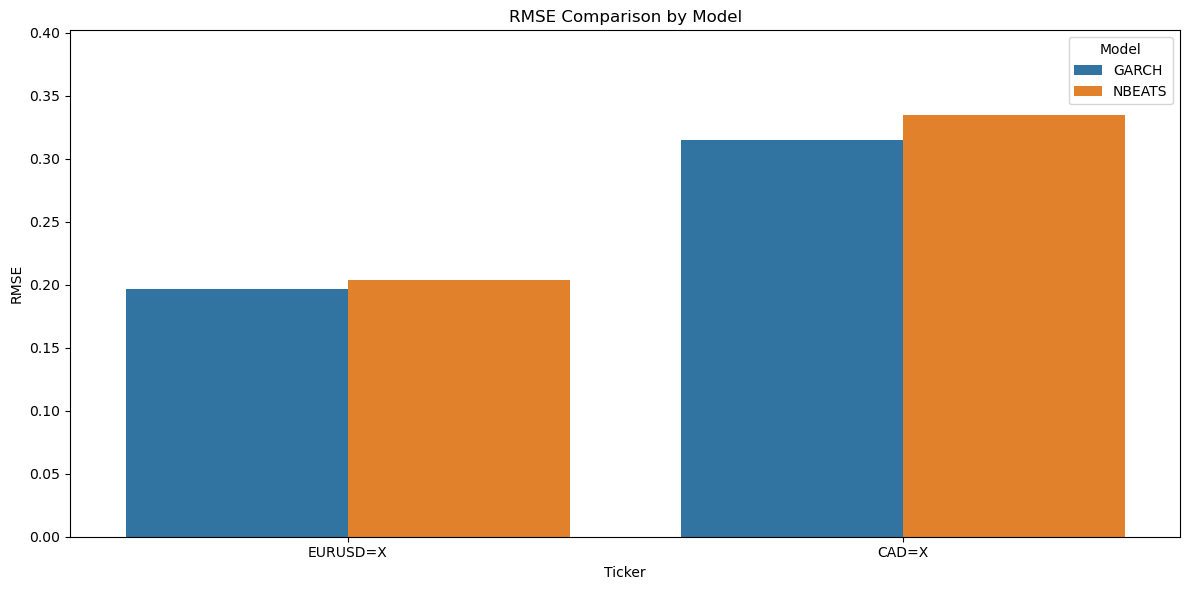

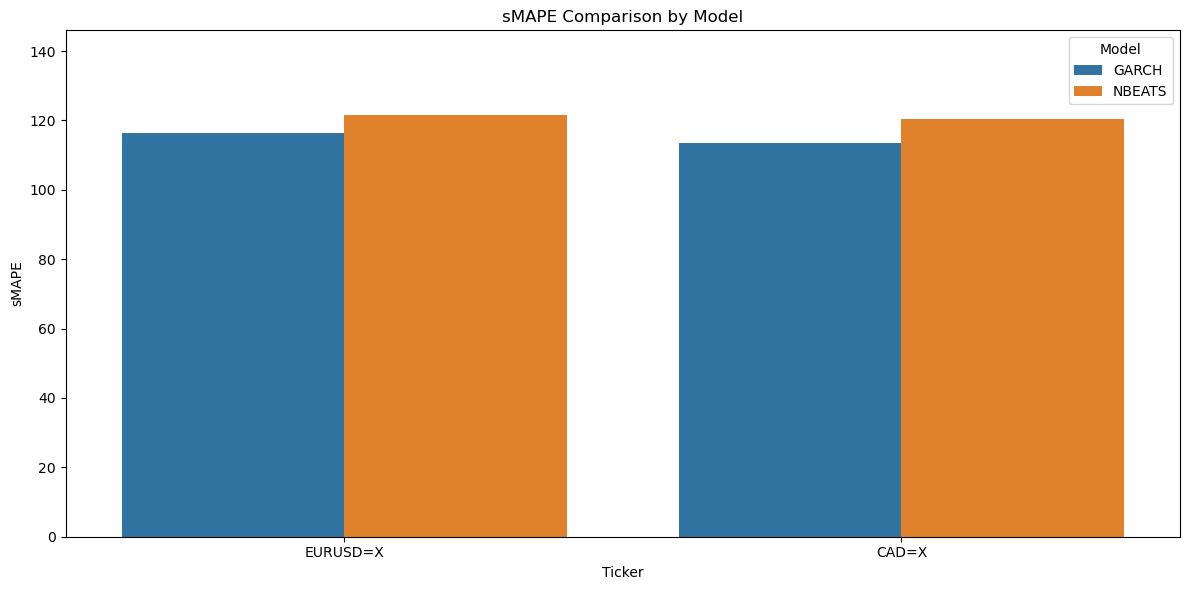

In [5]:
# Bar plot comparaison
df = performance.stack(level=0).reset_index()
df.columns = ['Ticker', 'Model', 'RMSE', 'sMAPE']

metrics = performance.columns.levels[1].values 
 
for metric in metrics:
   plt.figure(figsize=(12,6)) 
    
   sns.barplot(
      x='Ticker', 
      y=metric, 
      data=df, 
      hue='Model')

   plt.title(f'{metric} Comparison by Model')
   plt.ylim(0, df[metric].max()+df[metric].max()*0.2)
   plt.legend(title='Model')

   plt.tight_layout()
   plt.show()

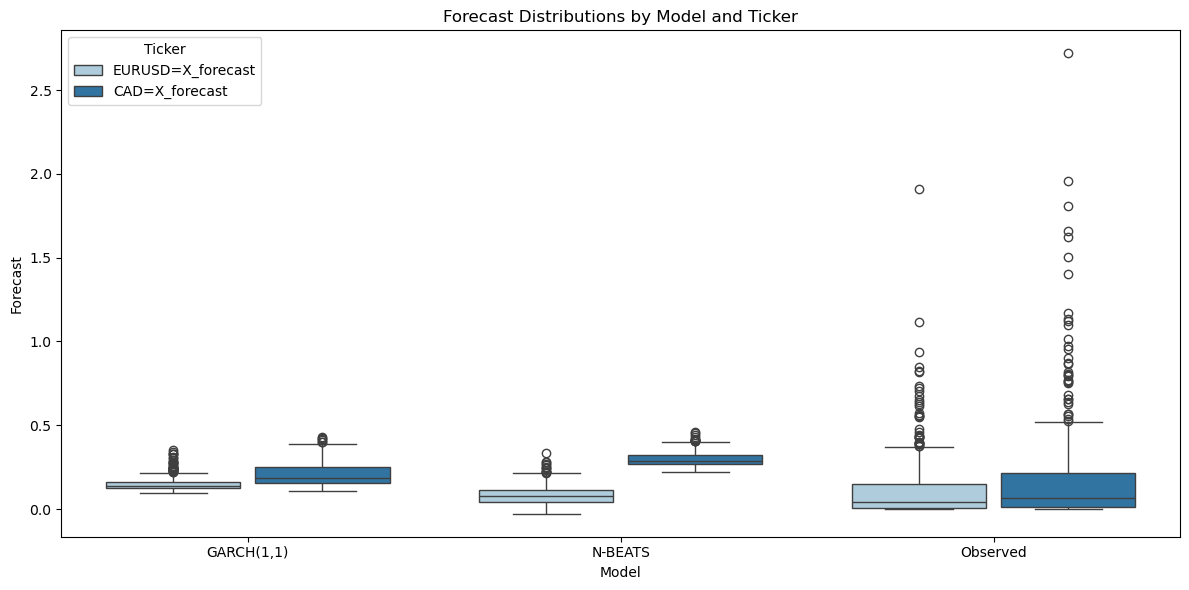

In [6]:
# boxplot of forecasts
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=forecasts,
    x="Model",
    y="Forecast",
    hue="Ticker",
    palette="Paired",
    gap=0.1
)

plt.title("Forecast Distributions by Model and Ticker")
plt.ylabel("Forecast")
plt.xlabel("Model")
plt.tight_layout()

# save 
# plt.savefig("forecast_boxplots.png", dpi=300, bbox_inches="tight")

plt.show()

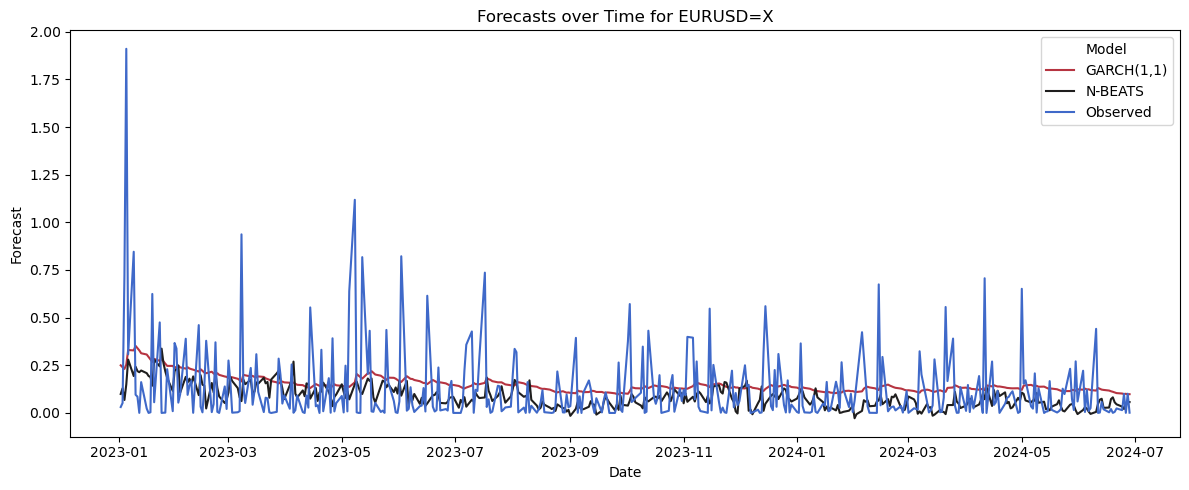

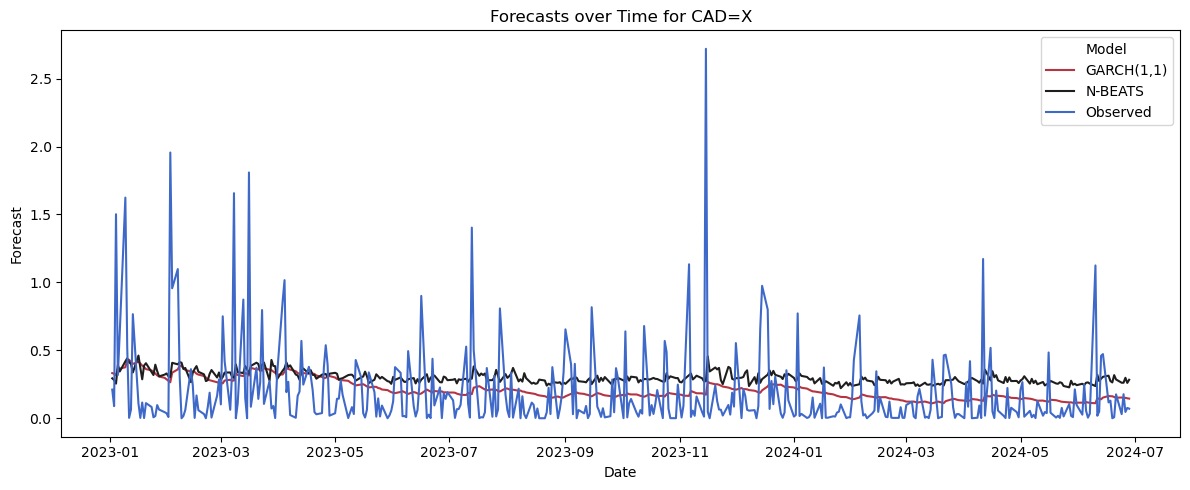

In [8]:
df = forecasts.copy()

df["Date"] = pd.to_datetime(df["Date"])
tickers = df["Ticker"].unique()

for ticker in tickers:
    plt.figure(figsize=(12, 5)) 

    sns.lineplot(
        data=df[df["Ticker"] == ticker],
        x="Date",
        y="Forecast",
        hue="Model",
        palette='icefire_r'
    )

    plt.title(f"Forecasts over Time for {ticker[:-9]}") 

    # save
    plt.savefig(f"../results/figures/Forecasts_Comparison_{ticker[:-9]}.png", dpi=300, bbox_inches="tight")

    plt.tight_layout()
    plt.show()